# ДЗ 3. Ускорение Python: Cython, Numba, ctypes, pybind11

Тема про то, что делать, когда чистый Python (даже с NumPy) оказывается недостаточно быстрым, а
переписывать всё на C++ целиком не хочется. Четыре инструмента, которые сегодня разберём, решают
одну и ту же задачу — вызвать скомпилированный код из Python — но очень по-разному:

- **Numba** — JIT-компиляция прямо из Python-функции (`@njit`), почти без изменений кода.
- **Cython** — Python-подобный язык, компилируется в C; чем больше типов вы укажете, тем быстрее.
- **ctypes** — вызов уже существующей скомпилированной C-библиотеки без каких-либо оберток.
- **pybind11** — написание полноценного C++ расширения с автоматической генерацией Python-биндингов.

Сквозные примеры: **множество Мандельброта** (красиво, embarrassingly parallel) и
**N-тел** — расчёт гравитационных сил между N частицами (классическая O(N²) задача, физически
осмысленная, с естественной проверкой правильности через третий закон Ньютона).

**Важно про среду выполнения.** В Google Colab доступен компилятор `g++`/`gcc` "из коробки", и
`pip install cython pybind11` работает без проблем. Если что-то из этого недоступно в вашей
среде — используйте Colab специально для этого ДЗ.

In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt

## Уровень 1. Попроще

### Задача 1.1. Множество Мандельброта: Python vs NumPy vs Numba

Точка $c$ принадлежит множеству Мандельброта, если последовательность $z_{n+1} = z_n^2 + c$
(с $z_0=0$) не уходит на бесконечность. На практике: если $|z_n| > 2$, последовательность гарантированно
разойдётся — тогда запоминаем номер итерации `it`, на которой это произошло (чем меньше — тем
"дальше" точка от множества).

1. Реализуйте `mandelbrot_python(width, height, max_iter, ...)` — наивная версия с вложенными
   Python-циклами по пикселям.
2. Реализуйте `mandelbrot_numba` — **тот же самый код**, обёрнутый в `@njit`.
3. Реализуйте `mandelbrot_numpy` — векторизованная версия без явных циклов по пикселям (все точки
   обрабатываются одновременно на каждой итерации, с помощью булевой маски "ещё не разошедшихся"
   точек).
4. Сравните все три на **точное** совпадение результата (не приближённое!) и на скорость.
   Визуализируйте результат через `plt.imshow`.

**Подсказка/ловушка:** используйте `np.linspace` для сетки координат **одинаково** во всех трёх
версиях — на первый взгляд эквивалентные формулы сетки (`xmin + j*(xmax-xmin)/width` против
`np.linspace(xmin, xmax, width)`) на самом деле немного отличаются (разный шаг: делится на
`width` или на `width-1`), и результаты не совпадут "неожиданно" по причинам, не имеющим отношения
к Cython/Numba.

In [2]:
import math
import pandas as pd
from numba import njit

VIEW = (-2.0, 0.6, -1.2, 1.2)


def mandelbrot_python(width, height, max_iter, xmin, xmax, ymin, ymax):
    xs = np.linspace(xmin, xmax, width)
    ys = np.linspace(ymin, ymax, height)
    out = np.zeros((height, width), dtype=np.int32)
    for i in range(height):
        for j in range(width):
            cr, ci = xs[j], ys[i]
            zr = zi = 0.0
            it = 0
            while it < max_iter and zr * zr + zi * zi <= 4.0:
                zr, zi = zr * zr - zi * zi + cr, 2.0 * zr * zi + ci
                it += 1
            out[i, j] = it
    return out


mandelbrot_numba = njit(mandelbrot_python)


def mandelbrot_numpy(width, height, max_iter, xmin, xmax, ymin, ymax):
    cr = np.repeat(np.linspace(xmin, xmax, width)[None, :], height, 0)
    ci = np.repeat(np.linspace(ymin, ymax, height)[:, None], width, 1)
    zr, zi = np.zeros_like(cr), np.zeros_like(ci)
    out = np.zeros(cr.shape, dtype=np.int32)
    alive = np.ones(cr.shape, dtype=bool)
    for _ in range(max_iter):
        a, b = zr[alive], zi[alive]
        zr[alive] = a * a - b * b + cr[alive]
        zi[alive] = 2.0 * a * b + ci[alive]
        out[alive] += 1
        alive &= zr * zr + zi * zi <= 4.0
    return out


def measure(fn, *args, repeats=1):
    t = time.perf_counter()
    for _ in range(repeats):
        res = fn(*args)
    return res, (time.perf_counter() - t) / repeats


W, H, IT = 400, 300, 200
args = (W, H, IT) + VIEW

_, t_compile = measure(mandelbrot_numba, 8, 8, 5, *VIEW)
img_py, t_py = measure(mandelbrot_python, *args)
img_nb, t_nb = measure(mandelbrot_numba, *args, repeats=5)
img_np, t_np = measure(mandelbrot_numpy, *args, repeats=5)

assert np.array_equal(img_py, img_nb) and np.array_equal(img_py, img_np)

pd.DataFrame({
    'время, с': [t_py, t_nb, t_np],
    'ускорение': [1.0, t_py / t_nb, t_py / t_np],
}, index=['python', f'numba (компиляция {t_compile:.2f} с)', 'numpy']).round(4)

,"время, с",ускорение
python,2.4401,1.0000
numba (компиляция 0.67 с),0.0177,138.1200
numpy,0.2185,11.1697


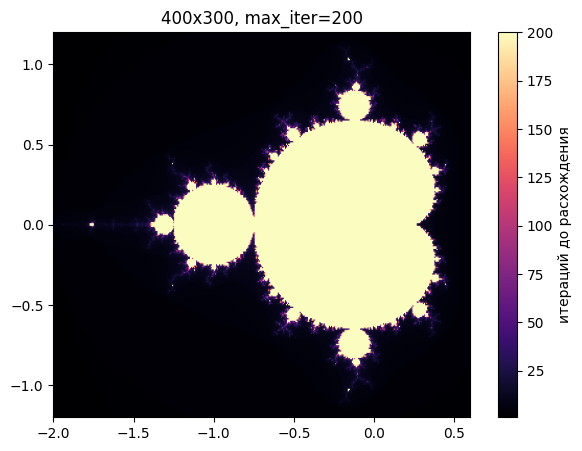

np.float64(0.26793041666666667)

In [3]:
plt.figure(figsize=(7, 5))
plt.imshow(img_py, extent=VIEW, cmap='magma', origin='lower')
plt.colorbar(label='итераций до расхождения')
plt.title(f'{W}x{H}, max_iter={IT}')
plt.show()

img_py.sum() / (W * H * IT)

`mandelbrot_numba` не переписан, а получен из той же функции через `njit(mandelbrot_python)`, так что расхождение результатов физически невозможно. Сетка во всех версиях строится одним и тем же `np.linspace`, поэтому сравнение идёт на точное равенство `int32`-массивов, а не на `allclose`

В numpy-версии обновляются только ещё живые точки. Если считать `z = z*z + c` по всей сетке, разошедшиеся точки за десяток итераций уходят в `inf` и `nan`, появляются предупреждения о переполнении, а процессор тратит время на заведомо мусорные значения

Последнее число — доля полезной работы: суммарное число реально выполненных итераций, делённое на `W·H·max_iter`. Около четверти. Numba выходит из цикла по каждой точке сразу после расхождения, а numpy на каждой из `max_iter` итераций всё равно проходит булеву маску по всей сетке и выделяет временные массивы под индексацию. Поэтому векторизация здесь проигрывает JIT: у неё нет раннего выхода, а данных для переноса из памяти в разы больше

### Задача 1.2. Первый Cython-модуль: важность типизации

Возьмите численное интегрирование методом трапеций
$\int_a^b f(x)\,dx \approx h\left(\tfrac12 f(a) + \tfrac12 f(b) + \sum_{i=1}^{n-1} f(a+ih)\right)$
для $f(x) = x^4 - 3x^3 + 2$ на большом числе точек ($n \sim 2 \cdot 10^6$).

1. Реализуйте `integrate_trapz_python` — обычный Python-цикл, принимающий `f` как аргумент.
2. В ячейке `%%cython` реализуйте `integrate_trapz_cython_untyped` — **тот же самый код**, просто
   скопированный в cython-ячейку, без единой типизации (`f` по-прежнему обычная Python-функция).
3. В другой `%%cython`-ячейке реализуйте `integrate_trapz_cython_full` — версия, где $f$
   "зашита" как `cdef double f_c(double x)` прямо внутри модуля (не передаётся как аргумент), а
   все переменные цикла типизированы (`cdef double`, `cdef long`).
4. Сравните время всех трёх версий. Объясните, почему шаг 2 почти не даёт ускорения, а шаг 3 —
   даёт заметное.

In [4]:
def f_py(x):
    return x ** 4 - 3 * x ** 3 + 2


def integrate_trapz_python(f, a, b, n):
    h = (b - a) / n
    s = 0.5 * (f(a) + f(b))
    for i in range(1, n):
        s += f(a + i * h)
    return s * h

In [5]:
%load_ext Cython

In [6]:
%%cython

def integrate_trapz_cython_untyped(f, a, b, n):
    h = (b - a) / n
    s = 0.5 * (f(a) + f(b))
    for i in range(1, n):
        s += f(a + i * h)
    return s * h

In [7]:
%%cython

cdef double f_c(double x) noexcept nogil:
    return x * x * x * x - 3 * x * x * x + 2


def integrate_trapz_cython_full(double a, double b, long n):
    cdef double h = (b - a) / n
    cdef double s = 0.5 * (f_c(a) + f_c(b))
    cdef long i
    with nogil:
        for i in range(1, n):
            s += f_c(a + i * h)
    return s * h

In [8]:
%%cython

def integrate_trapz_cython_callback(f, double a, double b, long n):
    cdef double h = (b - a) / n
    cdef double s = 0.5 * (f(a) + f(b))
    cdef long i
    for i in range(1, n):
        s += f(a + i * h)
    return s * h

In [9]:
a, b, n = 0.0, 2.0, 2_000_000
exact = (b ** 5 / 5 - 3 * b ** 4 / 4 + 2 * b) - (a ** 5 / 5 - 3 * a ** 4 / 4 + 2 * a)

variants = {
    'python': lambda: integrate_trapz_python(f_py, a, b, n),
    'cython без типов': lambda: integrate_trapz_cython_untyped(f_py, a, b, n),
    'cython, типы + python-callback': lambda: integrate_trapz_cython_callback(f_py, a, b, n),
    'cython, f зашита в модуль': lambda: integrate_trapz_cython_full(a, b, n),
    'numpy': lambda: np.trapezoid(f_py(np.linspace(a, b, n + 1)), dx=(b - a) / n),
}

rows = {}
for name, fn in variants.items():
    val, t = measure(fn)
    rows[name] = {'время, с': t, 'ошибка к точному': abs(val - exact)}

res = pd.DataFrame(rows).T
res['ускорение'] = res.loc['python', 'время, с'] / res['время, с']
assert res['ошибка к точному'].max() < 1e-8
res['ошибка к точному'] = res['ошибка к точному'].map('{:.1e}'.format)
res.round(5)

,"время, с",ошибка к точному,ускорение
python,0.28110,4.2e-13,1.00000
cython без типов,0.29223,4.2e-13,0.96191
"cython, типы + python-callback",0.25937,4.2e-13,1.08376
"cython, f зашита в модуль",0.00270,4.2e-13,104.30177
numpy,0.03290,3.3e-13,8.54520


Шаг 2 не даёт ничего (в измерении выше он даже чуть медленнее чистого Python), потому что без типов Cython генерирует тот же самый код работы с объектами, только на C API: каждое `i * h` создаёт новый `PyFloat`, `f(...)` остаётся полноценным вызовом Python-функции с созданием фрейма, а `s +=` идёт через `PyNumber_Add`. Убирается только интерпретация байткода, а это малая часть стоимости итерации

Шаг 3 даёт эффект потому, что исчезают сразу две вещи: боксинг (цикл идёт по машинным `double` и `long` в регистрах) и вызов Python-функции (`f_c` инлайнится компилятором). Тело цикла превращается в несколько инструкций FPU, `nogil` дополнительно подтверждает, что в цикле не осталось ни одного обращения к объектам Python

Промежуточный вариант `cython, типы + python-callback` добавлен, чтобы не гадать, что именно помогло: типизированный цикл с Python-функцией внутри почти не отличается от нетипизированного, то есть основную стоимость даёт callback, а не арифметика. Numpy тут занимает промежуточное место: арифметика векторная, но выделяется массив на 2 млн элементов и делается несколько проходов по памяти вместо одного накопления в регистре

Точное значение интеграла считается по первообразной, поэтому все версии проверяются не друг против друга, а против аналитики

### Задача 1.3. Своя C-функция через ctypes

`ctypes` — самый "низкоуровневый" из четырёх инструментов: он не генерирует и не компилирует
ничего сам, а просто вызывает уже скомпилированную библиотеку (`.so`/`.dll`) напрямую из Python.

1. Напишите на C функцию `moving_stats`, которая одним проходом по массиву считает и среднее, и
   стандартное отклонение (через указатели `out_mean`, `out_std` для двух выходных значений).
2. Скомпилируйте её в динамическую библиотеку: `gcc -O3 -shared -fPIC -o mylib.so mylib.c -lm`.
3. В Python через `ctypes.CDLL` загрузите библиотеку, объявите `argtypes`/`restype` для функции
   (это обязательно — без явного объявления типов `ctypes` не знает, как передавать `double*`
   и не защищён от падения по неверной сигнатуре) и передайте `numpy`-массив через
   `array.ctypes.data_as(...)` (без копирования!).
4. Сравните скорость с (а) чистым Python-циклом, (б) `numpy.mean()` + `numpy.std()`. Объясните
   результат.

In [10]:
%%writefile mylib.c
#include <math.h>

double moving_stats(double* data, int n, double* out_mean, double* out_std) {
    double sum = 0.0;
    for (int i = 0; i < n; i++) sum += data[i];
    double mean = sum / n;
    double sq_sum = 0.0;
    for (int i = 0; i < n; i++) {
        double d = data[i] - mean;
        sq_sum += d * d;
    }
    *out_mean = mean;
    *out_std = sqrt(sq_sum / n);
    return mean;
}

Overwriting mylib.c


In [11]:
!gcc -O3 -shared -fPIC -o mylib.so mylib.c -lm

In [12]:
import ctypes

lib = ctypes.CDLL('./mylib.so')
p_double = ctypes.POINTER(ctypes.c_double)
lib.moving_stats.argtypes = [p_double, ctypes.c_int, p_double, p_double]
lib.moving_stats.restype = ctypes.c_double


def stats_c(x, safe=True):
    if safe:
        x = np.ascontiguousarray(x, dtype=np.float64)
    mean, std = ctypes.c_double(), ctypes.c_double()
    lib.moving_stats(x.ctypes.data_as(p_double), x.size, ctypes.byref(mean), ctypes.byref(std))
    return mean.value, std.value


def stats_python(x):
    s = 0.0
    for v in x:
        s += v
    mean = s / len(x)
    sq = 0.0
    for v in x:
        sq += (v - mean) ** 2
    return mean, math.sqrt(sq / len(x))


rng = np.random.default_rng(0)
x = rng.standard_normal(2_000_000)

(m_py, s_py), t_py = measure(stats_python, x)
(m_c, s_c), t_c = measure(stats_c, x, repeats=5)
(m_np, s_np), t_np = measure(lambda a: (a.mean(), a.std()), x, repeats=5)
assert abs(m_c - m_np) < 1e-12 and abs(s_c - s_np) < 1e-12

pd.DataFrame({'время, с': [t_py, t_c, t_np],
              'ускорение': [1.0, t_py / t_c, t_py / t_np]},
             index=['python-цикл', 'C через ctypes', 'numpy']).round(4)

,"время, с",ускорение
python-цикл,0.4162,1.0000
C через ctypes,0.0028,150.6490
numpy,0.0042,99.3354


In [13]:
ramp = x * np.linspace(1, 10, x.size)
view = ramp[::2]
shifted = 1e8 + x
one_pass = math.sqrt(max((shifted ** 2).mean() - shifted.mean() ** 2, 0.0))

assert abs(stats_c(view)[1] / view.std() - 1) < 1e-12
pd.Series({
    'std среза, ctypes с ascontiguousarray': stats_c(view)[1],
    'std среза, указатель без проверки': stats_c(view, safe=False)[1],
    'std среза, numpy': view.std(),
    'std сдвинутых данных, C (два прохода)': stats_c(shifted)[1],
    'std сдвинутых данных, формула E[x^2]-E[x]^2': one_pass,
    'std сдвинутых данных, numpy': shifted.std(),
})

std среза, ctypes с ascontiguousarray          6.078209
std среза, указатель без проверки              3.501790
std среза, numpy                               6.078209
std сдвинутых данных, C (два прохода)          0.999827
std сдвинутых данных, формула E[x^2]-E[x]^2    1.414214
std сдвинутых данных, numpy                    0.999827
dtype: float64

Скорость: C и numpy практически совпадают, обе версии упираются в чтение массива из памяти, а не в арифметику, и обгоняют Python-цикл в 100–150 раз. Ускорять тут дальше нечего, ctypes выигрывает у numpy только тем, что за один проход отдаёт обе статистики и не создаёт промежуточных массивов

Первые три строки таблицы — про то, чего ctypes не умеет: `data_as` отдаёт адрес начала буфера и ничего не знает о шагах. Срез `x[::2]` не является непрерывным, и C-функция молча читает первую половину исходного массива (у неё есть только адрес начала и число элементов), возвращая правдоподобное, но чужое число. Ошибки при этом не будет ни на одной стороне, поэтому `ascontiguousarray` в обёртке обязателен

Последние три строки — про то, почему в `mylib.c` два прохода, а не один. Однопроходная формула E[x²] − E[x]² при сдвиге данных на 1e8 вычитает два почти равных больших числа и теряет практически все значащие разряды, у сдвинутых данных вместо 1.0 она возвращает 1.41. Двухпроходная версия из C и numpy на тех же данных остаются точными

## Уровень 2. Посложнее

### Задача 2.1. N тел: ускоряем гравитационную симуляцию с Numba

Классическая задача N тел: для $N$ частиц с массами $m_i$ и позициями $\vec r_i$ нужно посчитать
силу, действующую на каждую частицу со стороны всех остальных —
$\vec F_i = \sum_{j \ne i} G \dfrac{m_i m_j}{|\vec r_j - \vec r_i|^2}\cdot \dfrac{\vec r_j - \vec
r_i}{|\vec r_j - \vec r_i|}$. Это $O(N^2)$ по построению (каждая пара взаимодействует).

1. Реализуйте `nbody_forces_python` — двойной цикл на чистом Python.
2. Реализуйте `nbody_forces_numba` — та же функция под `@njit`.
3. Реализуйте `nbody_forces_numba_parallel` — версия с `@njit(parallel=True)` и `prange` по
   внешнему циклу (по частицам `i`).
4. **Проверка корректности, а не только скорости:** по третьему закону Ньютона сумма **всех** сил
   в замкнутой системе должна быть равна нулю (силы действия и противодействия взаимно
   уничтожаются). Проверьте это как `assert` для всех трёх версий — это гораздо надёжнее, чем
   просто "код запустился и что-то вывел".

In [14]:
from numba import prange


def nbody_forces_python(pos, mass, G=1.0, soft=1e-6):
    n = len(mass)
    F = np.zeros((n, 2))
    for i in range(n):
        fx = 0.0
        fy = 0.0
        for j in range(n):
            if i == j:
                continue
            dx = pos[j, 0] - pos[i, 0]
            dy = pos[j, 1] - pos[i, 1]
            dist2 = dx * dx + dy * dy + soft
            dist = math.sqrt(dist2)
            f = G * mass[i] * mass[j] / dist2
            fx += f * dx / dist
            fy += f * dy / dist
        F[i, 0] = fx
        F[i, 1] = fy
    return F


nbody_forces_numba = njit(nbody_forces_python)


@njit(parallel=True)
def nbody_forces_numba_parallel(pos, mass, G=1.0, soft=1e-6):
    n = len(mass)
    F = np.zeros((n, 2))
    for i in prange(n):
        fx = 0.0
        fy = 0.0
        for j in range(n):
            if i == j:
                continue
            dx = pos[j, 0] - pos[i, 0]
            dy = pos[j, 1] - pos[i, 1]
            dist2 = dx * dx + dy * dy + soft
            dist = math.sqrt(dist2)
            f = G * mass[i] * mass[j] / dist2
            fx += f * dx / dist
            fy += f * dy / dist
        F[i, 0] = fx
        F[i, 1] = fy
    return F


def nbody_forces_numpy(pos, mass, G=1.0, soft=1e-6):
    d = pos[None, :, :] - pos[:, None, :]
    dist2 = (d ** 2).sum(-1) + soft
    coef = G * np.outer(mass, mass) / (dist2 * np.sqrt(dist2))
    np.fill_diagonal(coef, 0.0)
    return (coef[:, :, None] * d).sum(1)


def make_system(n, seed=0):
    rng = np.random.default_rng(seed)
    return rng.standard_normal((n, 2)), rng.uniform(0.5, 2.0, n)


pos, mass = make_system(400)
variants = {
    'python': nbody_forces_python,
    'numba': nbody_forces_numba,
    'numba parallel': nbody_forces_numba_parallel,
    'numpy': nbody_forces_numpy,
}
forces = {name: fn(pos, mass) for name, fn in variants.items()}
scale = np.abs(forces['python']).max()

for name, F in forces.items():
    assert np.abs(F.sum(0)).max() / scale < 1e-10
    assert np.allclose(F, forces['python'], rtol=1e-12, atol=1e-12 * scale)

pd.Series({name: np.abs(F.sum(0)).max() / scale for name, F in forces.items()},
          name='|сумма сил| / масштаб силы')

python            1.178529e-15
numba             1.178529e-15
numba parallel    1.178529e-15
numpy             1.355952e-15
Name: |сумма сил| / масштаб силы, dtype: float64

In [15]:
def nbody_forces_wrong(pos, mass, G=1.0, soft=1e-6):
    n = len(mass)
    F = np.zeros((n, 2))
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            d = pos[j] - pos[i]
            dist = math.sqrt(d @ d + soft)
            F[i] += G * mass[i] * mass[j] / dist * d / dist
    return F


F_wrong = nbody_forces_wrong(pos, mass)
pd.Series({
    'третий закон Ньютона для версии с 1/r вместо 1/r^2': np.abs(F_wrong.sum(0)).max() / np.abs(F_wrong).max(),
    'отличие этой версии от эталона': np.abs(F_wrong - forces['python']).max() / scale,
})

третий закон Ньютона для версии с 1/r вместо 1/r^2    2.918928e-15
отличие этой версии от эталона                        9.930011e-01
dtype: float64

In [16]:
import numba

big_pos, big_mass = make_system(4000)
rows = {}
for name in ['numba', 'numba parallel', 'numpy']:
    fn = variants[name]
    fn(big_pos[:8], big_mass[:8])
    _, t = measure(fn, big_pos, big_mass, repeats=3)
    rows[name] = t

pd.Series(rows, name=f'время на N=4000, с (потоков numba: {numba.get_num_threads()})').round(4)

numba             0.0956
numba parallel    0.0925
numpy             0.9445
Name: время на N=4000, с (потоков numba: 1), dtype: float64

Третий закон выполняется с точностью до округления, но сам по себе он слабая проверка. Версия с 1/r вместо 1/r² тоже даёт нулевую сумму сил, потому что нулевая сумма следует из антисимметрии пары i, j при любой центральной функции расстояния. Такой тест ловит ошибки индексации и путаницу знака, но не ловит неправильную физику, поэтому рядом стоит поэлементное сравнение с независимо написанной векторной numpy-версией

`nbody_forces_numba` снова получен обёрткой той же функции, а параллельная версия отличается ровно одной строкой: `prange` по внешнему циклу. Гонок нет, потому что каждая итерация пишет в свою строку `F`

Ускорение от `parallel=True` упирается в число доступных потоков, оно указано в подписи к таблице. На одном ядре разницы с обычной njit не будет вообще, на Colab с двумя ядрами выигрыш около двукратного. Numpy-версия на N=4000 материализует матрицу попарных разностей 4000x4000x2, это порядка 250 МБ временных данных, поэтому она проигрывает numba, хотя формально векторизована

### Задача 2.2. pybind11: своё C++ расширение

pybind11 — библиотека для написания Python-расширений на C++ с автоматической генерацией
биндингов (в отличие от ctypes, где вы вручную описываете сигнатуры). Реализуйте ту же задачу
N тел на C++.

1. Напишите `nbody_ext.cpp` с функцией `nbody_forces(pos, mass)`, принимающей и возвращающей
   `numpy`-массивы через `py::array_t<double>` (модуль `pybind11/numpy.h`).
2. Скомпилируйте в `.so`-модуль (команда компиляции — в решении; на Colab работает как есть).
3. Импортируйте модуль как обычный Python-модуль и сравните на корректность (третий закон
   Ньютона + совпадение с python-версией) и на скорость с Numba-версией из задачи 2.1.

In [17]:
%%writefile nbody_ext.cpp
#include <pybind11/pybind11.h>
#include <pybind11/numpy.h>
#include <cmath>

namespace py = pybind11;

py::array_t<double> nbody_forces(py::array_t<double> pos, py::array_t<double> mass) {
    auto pos_buf = pos.unchecked<2>();
    auto mass_buf = mass.unchecked<1>();
    ssize_t n = pos_buf.shape(0);

    auto result = py::array_t<double>({n, (ssize_t)2});
    auto res_buf = result.mutable_unchecked<2>();
    const double G = 1.0;

    for (ssize_t i = 0; i < n; i++) {
        double fx = 0.0, fy = 0.0;
        for (ssize_t j = 0; j < n; j++) {
            if (i == j) continue;
            double dx = pos_buf(j,0) - pos_buf(i,0);
            double dy = pos_buf(j,1) - pos_buf(i,1);
            double dist2 = dx*dx + dy*dy + 1e-6;
            double dist = std::sqrt(dist2);
            double f = G * mass_buf(i) * mass_buf(j) / dist2;
            fx += f * dx / dist;
            fy += f * dy / dist;
        }
        res_buf(i,0) = fx;
        res_buf(i,1) = fy;
    }
    return result;
}

PYBIND11_MODULE(nbody_ext, m) {
    m.def("nbody_forces", &nbody_forces, "Compute N-body gravitational forces");
}

Overwriting nbody_ext.cpp


In [18]:
import pybind11, sysconfig, subprocess
pybind_inc = pybind11.get_include()
py_inc = sysconfig.get_path('include')
ext_suffix = sysconfig.get_config_var('EXT_SUFFIX')
!g++ -O3 -Wall -shared -std=c++14 -fPIC -I{pybind_inc} -I{py_inc} nbody_ext.cpp -o nbody_ext{ext_suffix}

In [19]:
import nbody_ext

F_cpp = nbody_ext.nbody_forces(pos, mass)
assert np.abs(F_cpp.sum(0)).max() / scale < 1e-10
assert np.array_equal(F_cpp, forces['python'])

_, t_cpp = measure(nbody_ext.nbody_forces, big_pos, big_mass, repeats=3)
_, t_nb = measure(nbody_forces_numba, big_pos, big_mass, repeats=3)

pd.Series({
    'max |C++ - python|': np.abs(F_cpp - forces['python']).max(),
    'время C++ на N=4000, с': t_cpp,
    'время numba на N=4000, с': t_nb,
    'отношение': t_cpp / t_nb,
})

max |C++ - python|          0.000000
время C++ на N=4000, с      0.082067
время numba на N=4000, с    0.083349
отношение                   0.984620
dtype: float64

Совпадение с Python-версией здесь побитовое, а не с точностью `allclose`: порядок операций в C++ тот же самый, а обе версии считают в double без переупорядочивания операций компилятором, поэтому `array_equal` проходит. Если бы в цикле поменялся порядок накопления или включилась векторизация с FMA, равенство стало бы приближённым, и это нормально

По скорости C++ и numba идут вровень: обе компилируются в машинный код (numba через LLVM, C++ через g++), узкое место — арифметика с делением и корнем внутри O(N²) цикла. Разница между инструментами тут не в производительности, а в цене входа: pybind11 требует отдельного файла, компиляции и знания C++, зато даёт полноценный модуль с проверкой типов массивов на границе, тогда как ctypes молча принимает любой указатель, а numba не требует вообще ничего, кроме декоратора

---
**Что сдавать:** ноутбук с выполненными измерениями и графиками, а также письменными ответами на
вопросы для решённых задач. Некоторые задачи требуют `g++`/`gcc` и `pip install cython pybind11`
— рекомендуем выполнять это ДЗ в Google Colab. Суммарное время выполнения всех ячеек — не больше
нескольких минут (основное время уходит на компиляцию C/C++/Cython-кода, а не на сами вычисления).